In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %pip install --quiet seaborn shap
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, VotingRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import joblib
import shap

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
df = pd.read_csv('airbnb_processed_data_multimodal (1).csv')
print(f"Loaded dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Drop text_quality_percentile — computed on full dataset in preprocessing
# so retaining it would constitute data leakage into the test set
if 'text_quality_percentile' in df.columns:
    df = df.drop(columns=['text_quality_percentile'])
    print("Dropped text_quality_percentile (preprocessing leakage)")

# Safety check — price_per_person must not be present
if 'price_per_person' in df.columns:
    df = df.drop(columns=['price_per_person'])
    print("Dropped price_per_person (data leakage)")

print(f"\nFinal shape after safety drops: {df.shape}")

Loaded dataset shape: (6562, 292)
Memory usage: 9.10 MB
Dropped text_quality_percentile (preprocessing leakage)

Final shape after safety drops: (6562, 291)


In [3]:
def get_feature_groups(columns):
    bert_name   = [c for c in columns if c.startswith('name_bert_')]
    bert_desc   = [c for c in columns if c.startswith('desc_bert_')]
    resnet      = [c for c in columns if c.startswith('img_resnet_')]
    has_picture = [c for c in columns if c == 'has_picture']

    deep_learning_cols = set(bert_name + bert_desc + resnet + has_picture)
    structured = [c for c in columns
                  if c not in deep_learning_cols and c != 'price']

    print(f"Structured features:  {len(structured)}")
    print(f"BERT name features:   {len(bert_name)}")
    print(f"BERT desc features:   {len(bert_desc)}")
    print(f"ResNet50 features:    {len(resnet)}")
    print(f"has_picture:          {len(has_picture)}")

    return {
        'structured': structured,
        'bert_name':  bert_name,
        'bert_desc':  bert_desc,
        'resnet':     resnet,
        'has_picture':has_picture
    }

feature_groups = get_feature_groups(df.columns.tolist())

Structured features:  193
BERT name features:   32
BERT desc features:   32
ResNet50 features:    32
has_picture:          1


In [4]:
target_col = 'price'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"\nTarget statistics:")
print(y.describe())

# ── Split FIRST ──────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\nTraining set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

# ── Fill missing values using TRAIN statistics only ───────────────────────────
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)


Features: 290  |  Samples: 6562

Target statistics:
count    6562.000000
mean      112.004745
std       112.317646
min        22.000000
25%        55.000000
50%        90.000000
75%       129.000000
max      1012.095000
Name: price, dtype: float64

Training set:   (4199, 290)
Validation set: (1050, 290)
Test set:       (1313, 290)


In [5]:
# ── Step 1: Remove high-missing features ─────────────────────────────────────
missing_threshold = 0.1
missing_pct = X_train.isnull().sum() / len(X_train)
high_missing_cols = missing_pct[missing_pct > missing_threshold].index.tolist()
X_train = X_train.drop(columns=high_missing_cols)
X_val   = X_val.drop(columns=[c for c in high_missing_cols if c in X_val.columns])
X_test  = X_test.drop(columns=[c for c in high_missing_cols if c in X_test.columns])
print(f"Removed {len(high_missing_cols)} high-missing features")

# ── Step 2: Variance threshold fitted on X_train ─────────────────────────────
var_sel = VarianceThreshold(threshold=0.005)
var_sel.fit(X_train)
selected_var = X_train.columns[var_sel.get_support()].tolist()
X_train = X_train[selected_var]
X_val   = X_val[[c for c in selected_var if c in X_val.columns]]
X_test  = X_test[[c for c in selected_var if c in X_test.columns]]
print(f"After variance filter: {X_train.shape[1]} features")

# ── Step 3: Correlation removal fitted on X_train ────────────────────────────
def remove_highly_correlated_features(df_train, threshold=0.90):
    """Remove highly correlated features. Never removes deep learning features."""
    corr_matrix = df_train.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    # Protect deep learning features from removal
    to_drop = [c for c in to_drop
               if not c.startswith(('name_bert_', 'desc_bert_',
                                    'img_resnet_', 'has_picture'))]
    return to_drop

dropped_corr = remove_highly_correlated_features(X_train, threshold=0.90)
X_train = X_train.drop(columns=dropped_corr)
X_val   = X_val.drop(columns=[c for c in dropped_corr if c in X_val.columns])
X_test  = X_test.drop(columns=[c for c in dropped_corr if c in X_test.columns])
print(f"Removed {len(dropped_corr)} highly correlated features")
print(f"After correlation filter: {X_train.shape[1]} features")


Removed 0 high-missing features
After variance filter: 267 features
Removed 9 highly correlated features
After correlation filter: 258 features



Fitting Random Forest for feature importance (train only)...
Top 20 Most Important Features:
                       feature  importance
0                 accommodates    0.146377
9    host_total_listings_count    0.098757
234  room_type_Entire home/apt    0.023655
2                     bedrooms    0.018020
232       overall_text_quality    0.017454
148            avg_word_length    0.016145
146                desc_length    0.014329
35               img_resnet_17    0.013310
16          people_per_bedroom    0.013230
14                   longitude    0.013010
174                name_bert_3    0.012725
1                    bathrooms    0.012293
203               desc_bert_17    0.011825
21                img_resnet_3    0.010932
181                desc_bert_6    0.010268
20                img_resnet_2    0.009739
221               desc_bert_26    0.009503
191               desc_bert_11    0.009477
194               name_bert_13    0.009465
182                name_bert_7    0.009290


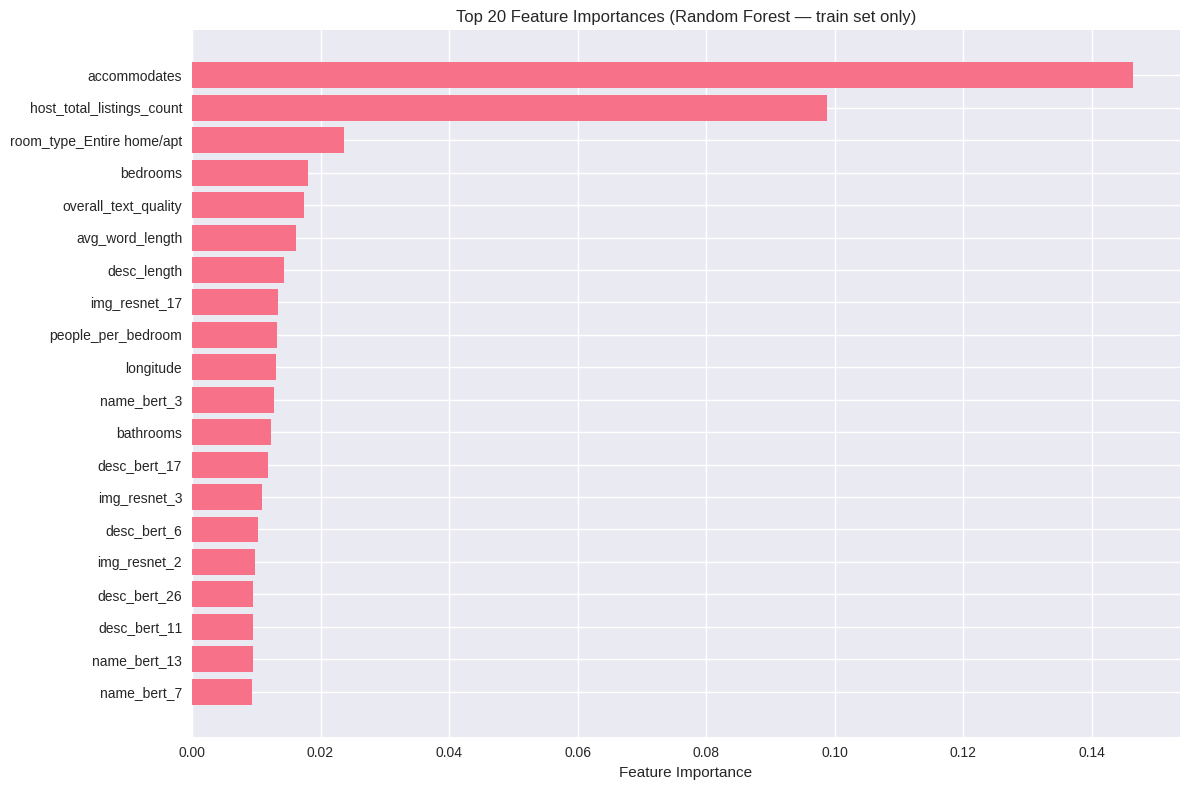

In [6]:
print("\nFitting Random Forest for feature importance (train only)...")
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20).to_string())

# Plot
plt.figure(figsize=(12, 8))
plt.barh(feature_importance.head(20)['feature'][::-1],
         feature_importance.head(20)['importance'][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances (Random Forest — train set only)')
plt.tight_layout()
plt.show()


In [7]:
# ── Step 5: Select top 150 — always keep ALL deep learning features ───────────
top_150 = feature_importance.head(150)['feature'].tolist()
dl_features = [c for c in X_train.columns
               if c.startswith(('name_bert_', 'desc_bert_',
                                'img_resnet_', 'has_picture'))]
top_features = top_150 + [f for f in dl_features if f not in set(top_150)]

X_train = X_train[top_features]
X_val   = X_val[[c for c in top_features if c in X_val.columns]]
X_test  = X_test[[c for c in top_features if c in X_test.columns]]

print(f"\nFinal feature count: {X_train.shape[1]}")
print(f"  of which DL features: {len([c for c in X_train.columns if c.startswith(('name_bert_','desc_bert_','img_resnet_','has_picture'))])}")




Final feature count: 151
  of which DL features: 97


In [8]:
# CELL 6 — Scaling (for linear models only — tree models use unscaled data)
# =============================================================================

# Fit scaler on X_train only
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)
print("Scaler fitted on X_train only — applied to val and test.")

Scaler fitted on X_train only — applied to val and test.


In [9]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Comprehensive model evaluation."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

def plot_predictions(y_true, y_pred, model_name="Model"):
    """Actual vs predicted + residual plot."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_true, y_pred, alpha=0.4, s=10)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', lw=2)
    axes[0].set_xlabel('Actual Price (£)')
    axes[0].set_ylabel('Predicted Price (£)')
    axes[0].set_title(f'{model_name}: Actual vs Predicted')

    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.4, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted Price (£)')
    axes[1].set_ylabel('Residuals (£)')
    axes[1].set_title(f'{model_name}: Residual Plot')

    plt.tight_layout()
    plt.show()

Training Linear Regression...
  Train R²: 0.3252  RMSE: £91.10
  Val   R²: 0.3230  RMSE: £88.75
Training Ridge Regression...
  Train R²: 0.3252  RMSE: £91.10
  Val   R²: 0.3233  RMSE: £88.73
Training Lasso Regression...
  Train R²: 0.3065  RMSE: £92.34
  Val   R²: 0.3274  RMSE: £88.46
Training Decision Tree...
  Train R²: 0.9999  RMSE: £1.10
  Val   R²: -0.4712  RMSE: £130.83
Training Random Forest...
  Train R²: 0.9032  RMSE: £34.50
  Val   R²: 0.3958  RMSE: £83.84


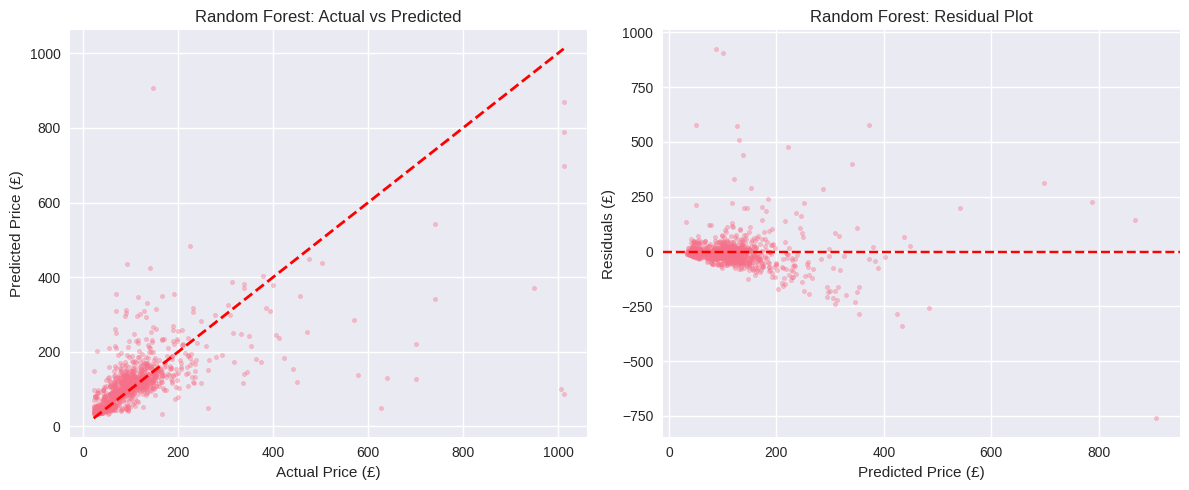


Baseline Model Results:
                       Model      RMSE      MAE      R²     MAPE
0  Linear Regression (Train)   91.0954  45.3277  0.3252  46.1495
1    Linear Regression (Val)   88.7454  44.3172  0.3230  48.1315
2   Ridge Regression (Train)   91.0956  45.3072  0.3252  46.1191
3     Ridge Regression (Val)   88.7295  44.2917  0.3233  48.0986
4   Lasso Regression (Train)   92.3437  43.2714  0.3065  42.3737
5     Lasso Regression (Val)   88.4573  41.6145  0.3274  43.3406
6      Decision Tree (Train)    1.1035   0.0252  0.9999   0.0197
7        Decision Tree (Val)  130.8273  56.0853 -0.4712  51.8852
8      Random Forest (Train)   34.4978  15.4797  0.9032  14.4890
9        Random Forest (Val)   83.8421  39.2929  0.3958  38.4068


In [10]:
# =============================================================================
# CELL 8 — Baseline Models
# Linear models use scaled data; tree models use unscaled
# =============================================================================

baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Lasso Regression':  Lasso(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100,
                                               random_state=42, n_jobs=-1)
}

baseline_results = []

for name, model in baseline_models.items():
    print(f"Training {name}...")
    uses_scaling = name in ['Linear Regression', 'Ridge Regression',
                             'Lasso Regression']
    Xtr = X_train_scaled if uses_scaling else X_train
    Xvl = X_val_scaled   if uses_scaling else X_val

    model.fit(Xtr, y_train)
    train_res = evaluate_model(y_train, model.predict(Xtr), f"{name} (Train)")
    val_res   = evaluate_model(y_val,   model.predict(Xvl), f"{name} (Val)")
    baseline_results.extend([train_res, val_res])

    print(f"  Train R²: {train_res['R²']:.4f}  RMSE: £{train_res['RMSE']:.2f}")
    print(f"  Val   R²: {val_res['R²']:.4f}  RMSE: £{val_res['RMSE']:.2f}")

    if name == 'Random Forest':
        plot_predictions(y_val, model.predict(X_val), name)

baseline_df = pd.DataFrame(baseline_results)
print("\nBaseline Model Results:")
print(baseline_df.round(4).to_string())


In [11]:
# =============================================================================
# CELL 9 — Advanced Models (unscaled — tree-based)
# =============================================================================

advanced_models = {
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    )
}

advanced_results = []

for name, model in advanced_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    train_res = evaluate_model(y_train, model.predict(X_train), f"{name} (Train)")
    val_res   = evaluate_model(y_val,   model.predict(X_val),   f"{name} (Val)")
    advanced_results.extend([train_res, val_res])
    print(f"  Train R²: {train_res['R²']:.4f} | Val R²: {val_res['R²']:.4f}"
          f" | Val RMSE: £{val_res['RMSE']:.2f}")

advanced_df = pd.DataFrame(advanced_results)
print("\nAdvanced Model Results:")
print(advanced_df.round(4).to_string())

Training XGBoost...
  Train R²: 0.9515 | Val R²: 0.4201 | Val RMSE: £82.14
Training LightGBM...
  Train R²: 0.7967 | Val R²: 0.4298 | Val RMSE: £81.44
Training Gradient Boosting...
  Train R²: 0.9570 | Val R²: 0.3892 | Val RMSE: £84.30
Training Extra Trees...
  Train R²: 0.9999 | Val R²: 0.4602 | Val RMSE: £79.24

Advanced Model Results:
                       Model     RMSE      MAE      R²     MAPE
0            XGBoost (Train)  24.4128  16.7208  0.9515  18.7042
1              XGBoost (Val)  82.1378  37.8070  0.4201  37.6866
2           LightGBM (Train)  49.9981  26.3064  0.7967  26.7560
3             LightGBM (Val)  81.4440  38.5638  0.4298  39.3771
4  Gradient Boosting (Train)  22.9944  16.7544  0.9570  19.2622
5    Gradient Boosting (Val)  84.2993  39.4903  0.3892  39.8513
6        Extra Trees (Train)   1.1035   0.0252  0.9999   0.0197
7          Extra Trees (Val)  79.2422  36.9260  0.4602  37.0321


Best performing models for ensemble: ['Extra Trees', 'LightGBM', 'XGBoost']

Ensemble — Val R²: 0.4637  RMSE: £78.99


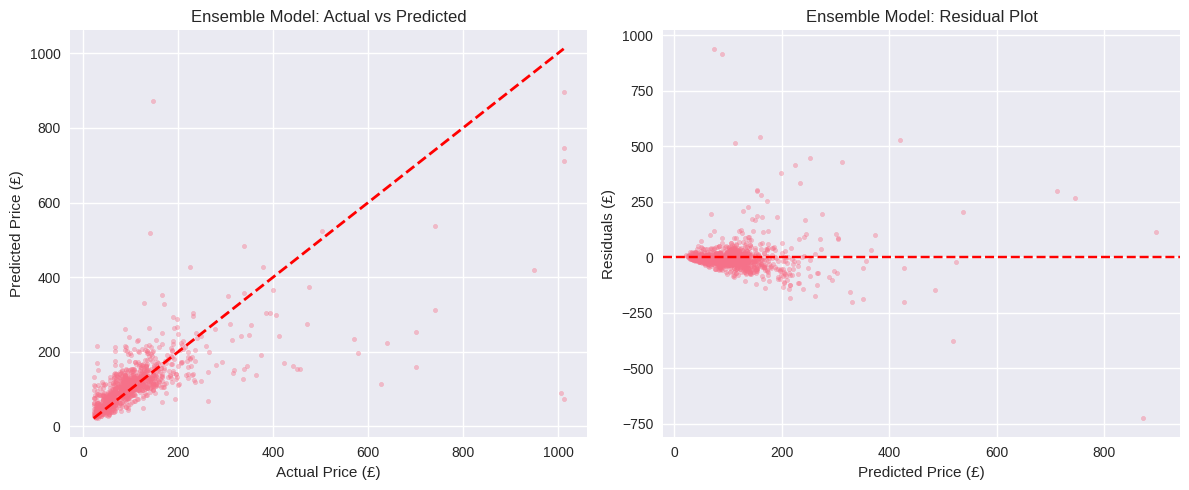

In [12]:
# =============================================================================
# CELL 10 — Ensemble of Best Models
# =============================================================================

all_results  = pd.concat([baseline_df, advanced_df])
val_only     = all_results[all_results['Model'].str.contains('Val')]
best_names   = (val_only.nlargest(3, 'R²')['Model']
                        .str.replace(r' \(Val\)', '', regex=True)
                        .tolist())
print(f"Best performing models for ensemble: {best_names}")

ensemble_map = {
    'XGBoost':       ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42)),
    'Random Forest': ('rf',  RandomForestRegressor(n_estimators=100, random_state=42)),
    'LightGBM':      ('lgb', lgb.LGBMRegressor(n_estimators=100, random_state=42,
                                                verbose=-1)),
    'Extra Trees':   ('et',  ExtraTreesRegressor(n_estimators=100, random_state=42)),
}

ensemble_estimators = [ensemble_map[n] for n in best_names if n in ensemble_map]

if len(ensemble_estimators) >= 2:
    voting_reg = VotingRegressor(estimators=ensemble_estimators[:3])
    voting_reg.fit(X_train, y_train)
    ens_res = evaluate_model(y_val, voting_reg.predict(X_val), "Ensemble (Val)")
    print(f"\nEnsemble — Val R²: {ens_res['R²']:.4f}  RMSE: £{ens_res['RMSE']:.2f}")
    plot_predictions(y_val, voting_reg.predict(X_val), "Ensemble Model")


In [13]:
# =============================================================================
# CELL 11 — Cross-Validation (on X_train only)
# =============================================================================

def perform_cv(model, X, y, cv=5, model_name="Model"):
    """5-fold CV on training data only."""
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmse_scores, r2_scores = [], []

    for tr_idx, vl_idx in kfold.split(X):
        Xtr_f, Xvl_f = X.iloc[tr_idx], X.iloc[vl_idx]
        ytr_f, yvl_f = y.iloc[tr_idx], y.iloc[vl_idx]
        model.fit(Xtr_f, ytr_f)
        preds = model.predict(Xvl_f)
        rmse_scores.append(np.sqrt(mean_squared_error(yvl_f, preds)))
        r2_scores.append(r2_score(yvl_f, preds))

    return {
        'Model':        model_name,
        'CV_RMSE_Mean': np.mean(rmse_scores),
        'CV_RMSE_Std':  np.std(rmse_scores),
        'CV_R2_Mean':   np.mean(r2_scores),
        'CV_R2_Std':    np.std(r2_scores)
    }

cv_models = {
    'XGBoost':      xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Random Forest':RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM':     lgb.LGBMRegressor(n_estimators=100, random_state=42,
                                       verbose=-1, n_jobs=-1)
}

cv_results = []
for name, model in cv_models.items():
    print(f"CV — {name}...")
    res = perform_cv(model, X_train, y_train, cv=5, model_name=name)
    cv_results.append(res)
    print(f"  CV R²:   {res['CV_R2_Mean']:.4f} (±{res['CV_R2_Std']:.4f})")
    print(f"  CV RMSE: £{res['CV_RMSE_Mean']:.2f} (±{res['CV_RMSE_Std']:.2f})")

cv_df = pd.DataFrame(cv_results)
print("\nCross-Validation Results Summary:")
print(cv_df.round(4).to_string())

CV — XGBoost...
  CV R²:   0.2855 (±0.0655)
  CV RMSE: £93.12 (±4.87)
CV — Random Forest...
  CV R²:   0.2644 (±0.0650)
  CV RMSE: £94.42 (±3.43)
CV — LightGBM...
  CV R²:   0.3109 (±0.0932)
  CV RMSE: £91.43 (±7.54)

Cross-Validation Results Summary:
           Model  CV_RMSE_Mean  CV_RMSE_Std  CV_R2_Mean  CV_R2_Std
0        XGBoost       93.1236       4.8727      0.2855     0.0655
1  Random Forest       94.4208       3.4292      0.2644     0.0650
2       LightGBM       91.4303       7.5352      0.3109     0.0932


ABLATION STUDY: Contribution of Each Feature Modality

Training: Baseline (Structured only) (54 features)...
  Val  R²: 0.4323  RMSE: £81.27
  Test R²: 0.5160  RMSE: £83.49

Training: + BERT (NLP embeddings) (118 features)...
  Val  R²: 0.4760  RMSE: £78.07
  Test R²: 0.5207  RMSE: £83.09

Training: + ResNet50 (Image features) (87 features)...
  Val  R²: 0.4397  RMSE: £80.74
  Test R²: 0.5033  RMSE: £84.58

Training: Full Multimodal (151 features)...
  Val  R²: 0.4260  RMSE: £81.72
  Test R²: 0.4907  RMSE: £85.65

ABLATION STUDY RESULTS
                             Features  Val R²  Val RMSE  Test R²  Test RMSE
Baseline (Structured only)       54.0  0.4323     81.27   0.5160      83.49
+ BERT (NLP embeddings)         118.0  0.4760     78.07   0.5207      83.09
+ ResNet50 (Image features)      87.0  0.4397     80.74   0.5033      84.58
Full Multimodal                 151.0  0.4260     81.72   0.4907      85.65


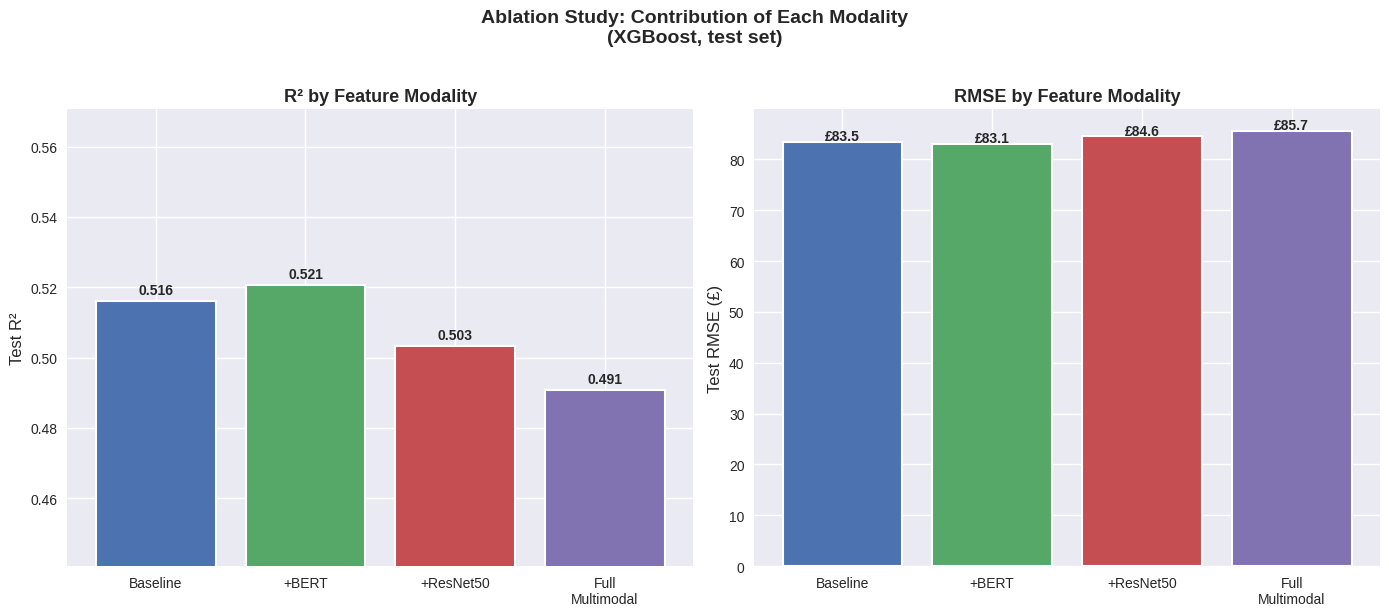

Saved: ablation_study.png


In [14]:
# =============================================================================
# CELL 12 — Ablation Study: Contribution of Each Modality
#
# Each configuration trained on X_train, evaluated on X_val AND X_test.
# Missing values filled with train_median (not 0) for structured features.
# =============================================================================

print("=" * 60)
print("ABLATION STUDY: Contribution of Each Feature Modality")
print("=" * 60)

all_train_cols = X_train.columns.tolist()

structured_cols = [c for c in all_train_cols
                   if not c.startswith(('name_bert_', 'desc_bert_',
                                        'img_resnet_', 'has_picture'))]
bert_cols   = [c for c in all_train_cols
               if c.startswith(('name_bert_', 'desc_bert_'))]
resnet_cols = [c for c in all_train_cols
               if c.startswith('img_resnet_') or c == 'has_picture']

ablation_configs = {
    'Baseline (Structured only)':  structured_cols,
    '+ BERT (NLP embeddings)':     structured_cols + bert_cols,
    '+ ResNet50 (Image features)': structured_cols + resnet_cols,
    'Full Multimodal':             all_train_cols,
}

ablation_results = {}

for config_name, feature_cols in ablation_configs.items():
    # Only use columns present in all three splits
    cols = [c for c in feature_cols
            if c in X_train.columns
            and c in X_val.columns
            and c in X_test.columns]

    print(f"\nTraining: {config_name} ({len(cols)} features)...")

    # Use train_median for structured features, 0 for DL features
    # (0 is correct for DL features — means no image/no text)
    abl_train_median = train_median[cols]

    model_abl = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1
    )
    model_abl.fit(X_train[cols].fillna(abl_train_median), y_train)

    y_pred_val  = model_abl.predict(X_val[cols].fillna(abl_train_median))
    y_pred_test = model_abl.predict(X_test[cols].fillna(abl_train_median))

    val_r2    = r2_score(y_val,  y_pred_val)
    val_rmse  = np.sqrt(mean_squared_error(y_val,  y_pred_val))
    test_r2   = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    ablation_results[config_name] = {
        'Features':  len(cols),
        'Val R²':    round(val_r2,   4),
        'Val RMSE':  round(val_rmse, 2),
        'Test R²':   round(test_r2,  4),
        'Test RMSE': round(test_rmse,2)
    }

    print(f"  Val  R²: {val_r2:.4f}  RMSE: £{val_rmse:.2f}")
    print(f"  Test R²: {test_r2:.4f}  RMSE: £{test_rmse:.2f}")

ablation_df = pd.DataFrame(ablation_results).T
print("\n" + "=" * 60)
print("ABLATION STUDY RESULTS")
print("=" * 60)
print(ablation_df.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
configs     = list(ablation_results.keys())
test_r2s    = [ablation_results[c]['Test R²']   for c in configs]
test_rmses  = [ablation_results[c]['Test RMSE'] for c in configs]
short_labels= ['Baseline', '+BERT', '+ResNet50', 'Full\nMultimodal']
colors      = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

axes[0].bar(short_labels, test_r2s, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Test R²', fontsize=12)
axes[0].set_title('R² by Feature Modality', fontsize=13, fontweight='bold')
axes[0].set_ylim(max(0, min(test_r2s) - 0.05), min(1, max(test_r2s) + 0.05))
for i, v in enumerate(test_r2s):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(short_labels, test_rmses, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Test RMSE (£)', fontsize=12)
axes[1].set_title('RMSE by Feature Modality', fontsize=13, fontweight='bold')
for i, v in enumerate(test_rmses):
    axes[1].text(i, v + 0.3, f'£{v:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Ablation Study: Contribution of Each Modality\n(XGBoost, test set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ablation_study.png")

In [15]:
# =============================================================================
# CELL 13 — Hyperparameter Tuning: XGBoost (on X_train only)
# =============================================================================

xgb_param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 6, 9],
    'learning_rate':   [0.01, 0.1, 0.2],
    'subsample':       [0.8, 0.9, 1.0],
    'colsample_bytree':[0.8, 0.9, 1.0]
}

def manual_randomized_search(model_class, param_grid, X, y,
                              n_iter=15, cv=3):
    """Randomised search with manual cross-validation on training data."""
    import random
    random.seed(42)

    best_score = float('inf')
    best_params = None

    param_combinations = []
    for _ in range(n_iter):
        params = {k: random.choice(v) for k, v in param_grid.items()}
        param_combinations.append(params)

    print(f"Testing {len(param_combinations)} parameter combinations...")

    for i, params in enumerate(param_combinations):
        kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
        cv_scores = []
        for tr_idx, vl_idx in kfold.split(X):
            model = model_class(random_state=42, n_jobs=-1, **params)
            model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            preds = model.predict(X.iloc[vl_idx])
            cv_scores.append(np.sqrt(mean_squared_error(y.iloc[vl_idx], preds)))

        mean_score = np.mean(cv_scores)
        if mean_score < best_score:
            best_score  = mean_score
            best_params = params
            print(f"  Combo {i+1}/{n_iter}: NEW BEST £{mean_score:.2f} — {params}")
        else:
            print(f"  Combo {i+1}/{n_iter}: £{mean_score:.2f}")

    return best_params, best_score

try:
    best_xgb_params, best_xgb_score = manual_randomized_search(
        xgb.XGBRegressor, xgb_param_grid, X_train, y_train, n_iter=15, cv=3
    )
    print(f"\nBest XGBoost params: {best_xgb_params}")
    print(f"Best CV RMSE: £{best_xgb_score:.2f}")

    best_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_xgb_params)
    best_xgb.fit(X_train, y_train)
    tuned_results = evaluate_model(y_val, best_xgb.predict(X_val), "Tuned XGBoost")
    print(f"Validation R²:   {tuned_results['R²']:.4f}")
    print(f"Validation RMSE: £{tuned_results['RMSE']:.2f}")

except Exception as e:
    print(f"Tuning error: {e} — using defaults")
    best_xgb_params = {'n_estimators': 200, 'max_depth': 6,
                       'learning_rate': 0.1, 'subsample': 0.8,
                       'colsample_bytree': 0.8}
    best_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_xgb_params)
    best_xgb.fit(X_train, y_train)
    tuned_results = evaluate_model(y_val, best_xgb.predict(X_val), "Default XGBoost")
    print(f"Validation R²:   {tuned_results['R²']:.4f}")
    print(f"Validation RMSE: £{tuned_results['RMSE']:.2f}")

Testing 15 parameter combinations...
  Combo 1/15: NEW BEST £93.79 — {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.9}
  Combo 2/15: £97.84
  Combo 3/15: £95.61
  Combo 4/15: £94.37
  Combo 5/15: £95.60
  Combo 6/15: £99.09
  Combo 7/15: NEW BEST £93.77 — {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.9}
  Combo 8/15: £94.64
  Combo 9/15: £94.53
  Combo 10/15: £96.66
  Combo 11/15: £94.13
  Combo 12/15: NEW BEST £93.12 — {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
  Combo 13/15: £96.78
  Combo 14/15: £96.09
  Combo 15/15: £96.60

Best XGBoost params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best CV RMSE: £93.12
Validation R²:   0.4305
Validation RMSE: £81.40


In [16]:
# =============================================================================
# CELL 14 — Hyperparameter Tuning: Random Forest (on X_train only)
# =============================================================================

rf_param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [10, 20, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':    ['sqrt', 'log2', None]
}

try:
    best_rf_params, best_rf_score = manual_randomized_search(
        RandomForestRegressor, rf_param_grid, X_train, y_train, n_iter=10, cv=3
    )
    print(f"\nBest RF params: {best_rf_params}")
    print(f"Best CV RMSE: £{best_rf_score:.2f}")

    best_rf = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
    best_rf.fit(X_train, y_train)
    rf_tuned_results = evaluate_model(y_val, best_rf.predict(X_val),
                                       "Tuned Random Forest")
    print(f"Validation R²:   {rf_tuned_results['R²']:.4f}")
    print(f"Validation RMSE: £{rf_tuned_results['RMSE']:.2f}")

except Exception as e:
    print(f"Tuning error: {e} — using defaults")
    best_rf_params = {'n_estimators': 200, 'max_depth': 20}
    best_rf = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
    best_rf.fit(X_train, y_train)
    rf_tuned_results = evaluate_model(y_val, best_rf.predict(X_val),
                                       "Default Random Forest")
    print(f"Validation R²:   {rf_tuned_results['R²']:.4f}")
    print(f"Validation RMSE: £{rf_tuned_results['RMSE']:.2f}")

# Select best model
print(f"\nModel Comparison:")
print(f"XGBoost       — R²: {tuned_results['R²']:.4f}  RMSE: £{tuned_results['RMSE']:.2f}")
print(f"Random Forest — R²: {rf_tuned_results['R²']:.4f}  RMSE: £{rf_tuned_results['RMSE']:.2f}")

if tuned_results['R²'] >= rf_tuned_results['R²']:
    final_model      = best_xgb
    final_model_name = "XGBoost"
    final_params     = best_xgb_params
    print(f"Selected: XGBoost (R² = {tuned_results['R²']:.4f})")
else:
    final_model      = best_rf
    final_model_name = "Random Forest"
    final_params     = best_rf_params
    print(f"Selected: Random Forest (R² = {rf_tuned_results['R²']:.4f})")

Testing 10 parameter combinations...
  Combo 1/10: NEW BEST £95.89 — {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}
  Combo 2/10: NEW BEST £94.35 — {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
  Combo 3/10: £97.31
  Combo 4/10: NEW BEST £93.55 — {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Combo 5/10: £97.28
  Combo 6/10: £94.52
  Combo 7/10: £95.84
  Combo 8/10: £96.07
  Combo 9/10: NEW BEST £93.54 — {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
  Combo 10/10: £94.49

Best RF params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Best CV RMSE: £93.54
Validation R²:   0.3812
Validation RMSE: £84.84

Model Comparison:
XGBoost       — R²: 0.4305  RMSE: £81.40
Random Fores

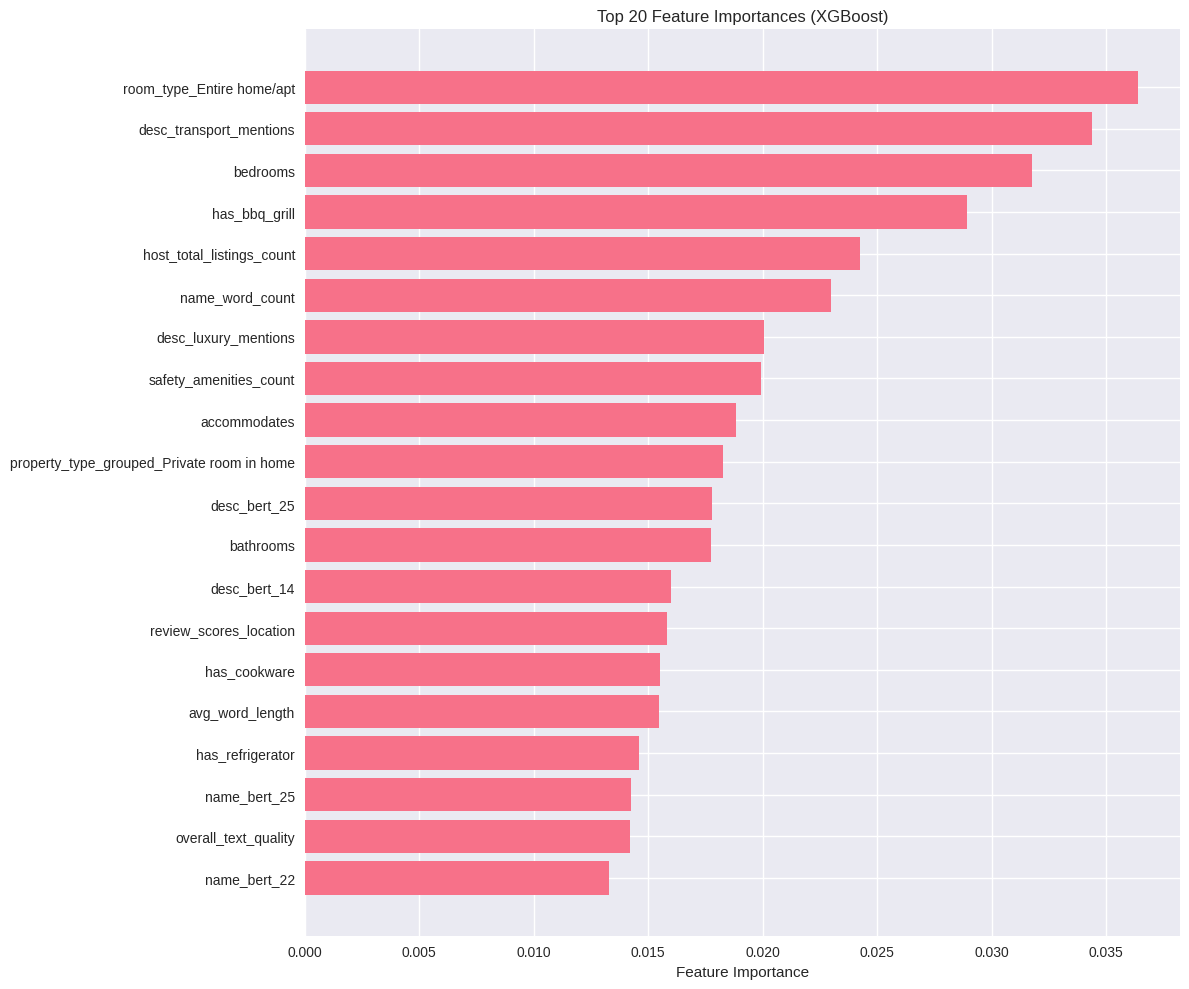

Top 10 Most Important Features:
  room_type_Entire home/apt.................... 0.0364
  desc_transport_mentions...................... 0.0344
  bedrooms..................................... 0.0318
  has_bbq_grill................................ 0.0289
  host_total_listings_count.................... 0.0242
  name_word_count.............................. 0.0230
  desc_luxury_mentions......................... 0.0201
  safety_amenities_count....................... 0.0199
  accommodates................................. 0.0189
  property_type_grouped_Private room in home... 0.0183

Calculating permutation importance...


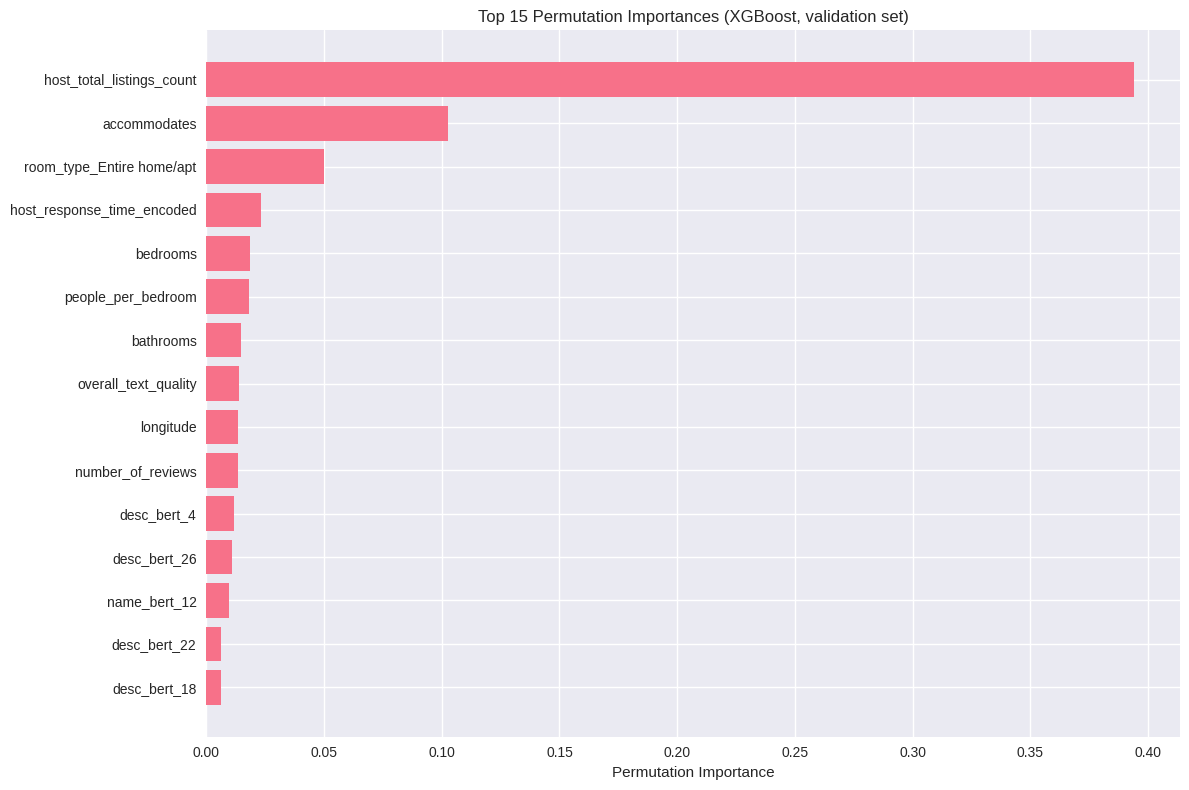

Top 10 Permutation Importance Features:
                       feature  importance       std
1    host_total_listings_count    0.393890  0.025444
0                 accommodates    0.102638  0.008290
2    room_type_Entire home/apt    0.050178  0.003749
32  host_response_time_encoded    0.023125  0.003691
3                     bedrooms    0.018645  0.003406
8           people_per_bedroom    0.018031  0.004512
11                   bathrooms    0.014517  0.001686
4         overall_text_quality    0.013988  0.004546
9                    longitude    0.013493  0.013432
78           number_of_reviews    0.013279  0.004403


In [17]:
# =============================================================================
# CELL 15 — Feature Importance & Permutation Importance
# =============================================================================

# Tree feature importance
if hasattr(final_model, 'feature_importances_'):
    fi_final = pd.DataFrame({
        'feature':    X_train.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 10))
    top20 = fi_final.head(20)
    plt.barh(top20['feature'][::-1], top20['importance'][::-1])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importances ({final_model_name})')
    plt.tight_layout()
    plt.show()

    print("Top 10 Most Important Features:")
    for _, row in fi_final.head(10).iterrows():
        print(f"  {row['feature']:.<45} {row['importance']:.4f}")

# Permutation importance (model-agnostic, more reliable)
print("\nCalculating permutation importance...")
perm_imp = permutation_importance(
    final_model, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature':    X_val.columns,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top15 = perm_df.head(15)
plt.barh(top15['feature'][::-1], top15['importance'][::-1])
plt.xlabel('Permutation Importance')
plt.title(f'Top 15 Permutation Importances ({final_model_name}, validation set)')
plt.tight_layout()
plt.show()

print("Top 10 Permutation Importance Features:")
print(perm_df.head(10).to_string())

Training final model on full training set...
Parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Features:   151
Training final XGBoost on full training set...

Final Model — Held-Out Test Set Performance
Test R²:   0.4809
Test RMSE: £86.47


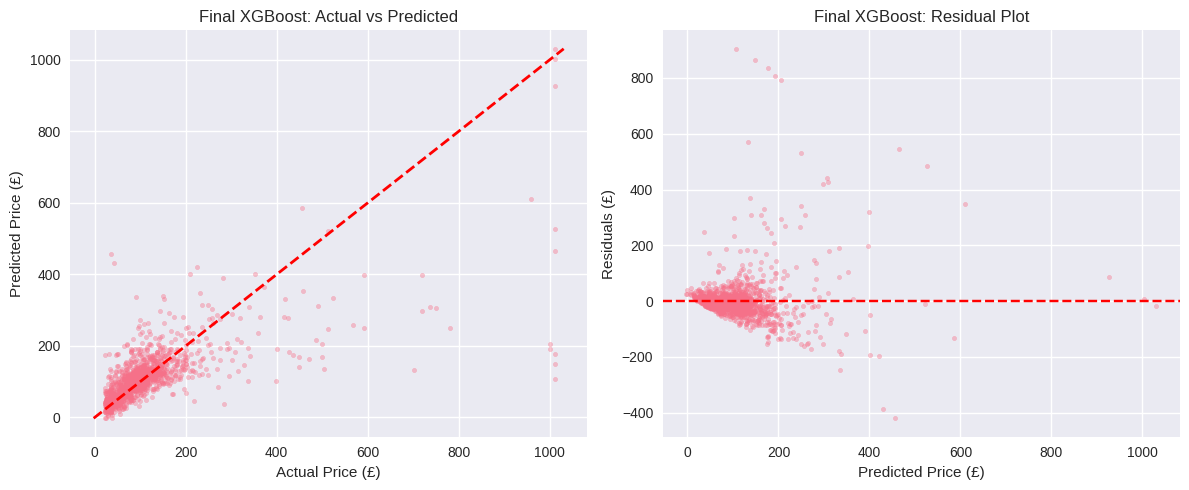


Running SHAP analysis on test set...


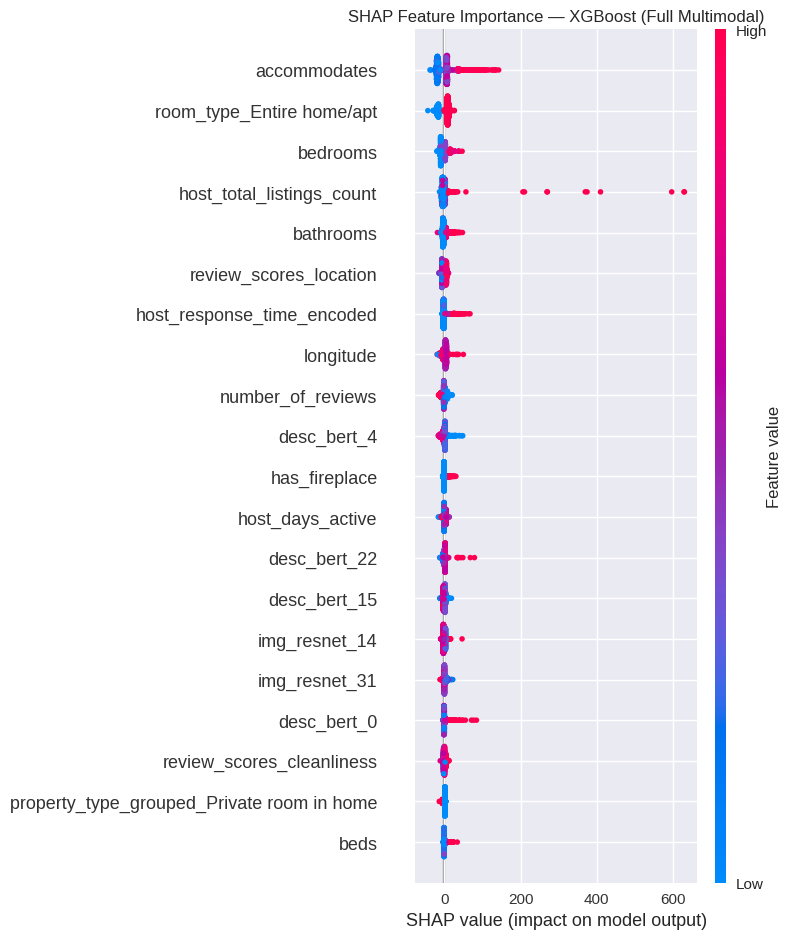

Saved: shap_summary.png


In [18]:
# =============================================================================
# CELL 16 — Final Model Training, SHAP & Streamlit Deployment Prep
#
# Uses the SAME model (best_xgb / tuned XGBoost) that was evaluated above.
# No new model is created — this trains it on the full training set
# with the same tuned parameters, then evaluates on the held-out test set.
# No scaling applied — XGBoost does not require feature scaling.
# =============================================================================

full_cols = X_train.columns.tolist()

print("Training final model on full training set...")
print(f"Parameters: {final_params}")
print(f"Features:   {len(full_cols)}")

# Create the correct model type based on what was selected
if final_model_name == "XGBoost":
    final_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, **final_params)
else:
    final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **final_params)

print(f"Training final {final_model_name} on full training set...")

#final_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, **final_params)
final_model.fit(X_train[full_cols], y_train)

# ── Evaluate on held-out test set ────────────────────────────────────────────
y_test_pred = final_model.predict(X_test[full_cols])
test_r2   = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\nFinal Model — Held-Out Test Set Performance")
print(f"Test R²:   {test_r2:.4f}")
print(f"Test RMSE: £{test_rmse:.2f}")

plot_predictions(y_test, y_test_pred, f"Final {final_model_name}")

# ── SHAP Analysis ─────────────────────────────────────────────────────────────
print("\nRunning SHAP analysis on test set...")
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test[full_cols])

plt.figure()
shap.summary_plot(
    shap_values, X_test[full_cols],
    max_display=20, show=False
)
plt.title(f'SHAP Feature Importance — {final_model_name} (Full Multimodal)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

In [19]:
# ── Save Everything for Streamlit ─────────────────────────────────────────────
joblib.dump(final_model,                              'airbnb_model.pkl')
joblib.dump(full_cols,                                'feature_columns.pkl')
joblib.dump(train_median[full_cols].to_dict(),        'feature_defaults.pkl')
# Note: no scaler saved — XGBoost does not use scaling.
# Streamlit app should apply train_median imputation, then predict directly.

print("\nFiles saved for Streamlit:")
print("  airbnb_model.pkl        — trained XGBoost model")
print("  feature_columns.pkl     — ordered list of feature names")
print("  feature_defaults.pkl    — train median per feature for imputation")
print("  ablation_study.png      — ablation study chart")
print("  shap_summary.png        — SHAP feature importance chart")
print("\nNote: pca_image.pkl, pca_name_bert.pkl, pca_desc_bert.pkl")
print("      and distilbert_tokenizer/ saved from preprocessing notebook.")


Files saved for Streamlit:
  airbnb_model.pkl        — trained XGBoost model
  feature_columns.pkl     — ordered list of feature names
  feature_defaults.pkl    — train median per feature for imputation
  ablation_study.png      — ablation study chart
  shap_summary.png        — SHAP feature importance chart

Note: pca_image.pkl, pca_name_bert.pkl, pca_desc_bert.pkl
      and distilbert_tokenizer/ saved from preprocessing notebook.
